<a href="https://colab.research.google.com/github/sthepaut/SAFRAN_ENSAI_2025/blob/ENSAI_students/performancemodel_ENSAI/notebook/Ensai_notebook2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !git clone https://github.com/Anonymous-GT11/SAFRAN_ENSAI_2025
!git clone -b ENSAI_students https://github.com/Anonymous-GT11/SAFRAN_ENSAI_2025

Cloning into 'SAFRAN_ENSAI_2025'...
remote: Enumerating objects: 144, done.
remote: Counting objects: 100% (144/144), done.
remote: Compressing objects: 100% (139/139), done.
remote: Total 144 (delta 53), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (144/144), 2.47 MiB | 9.48 MiB/s, done.
Resolving deltas: 100% (53/53), done.


In [2]:
# Verify that we have sucessfully clone the repo and go the place where the repo is stored
%cd /content/SAFRAN_ENSAI_2025
!ls

/content/SAFRAN_ENSAI_2025
Cie_0_Engine0.csv	performancemodel_ENSAI.zip
performancemodel_ENSAI	README.md


In [3]:
# install the package performance_model
%cd /content/SAFRAN_ENSAI_2025/performancemodel_ENSAI/
!pip install .

/content/SAFRAN_ENSAI_2025/performancemodel_ENSAI
Processing /content/SAFRAN_ENSAI_2025/performancemodel_ENSAI
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for performancemodel: filename=performancemodel-0.0.1-py3-none-any.whl size=30485 sha256=85a76051553975ffe8c9390f3b6279ee808ff849f409b16e05ff8948fe22467b
  Stored in directory: /tmp/pip-ephem-wheel-cache-nuu8cx6c/wheels/b4/6e/66/25433221b4a4d2ead6faf834b0fa81054260e4a8996e629ab9
Successfully built performancemodel


In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from tqdm import tqdm

from performancemodel.base_system import h_SCSF
from performancemodel.scenarios import simulate_degradation_trajectory, generate_multiple_trajectories
from performancemodel.plot import plot_trajectory


In [2]:
# import ga library
from geneticalgorithms.simple_genetic_algorithm import *

#  Genetic Algorithm  - Example with a single measurement

This diagram was created using PlantText.
    https://www.planttext.com/

![image](https://github.com/sthepaut/SAFRAN_ENSAI_2025/blob/ENSAI_students/performancemodel_ENSAI/notebook/diagram_GA2.png?raw=1)

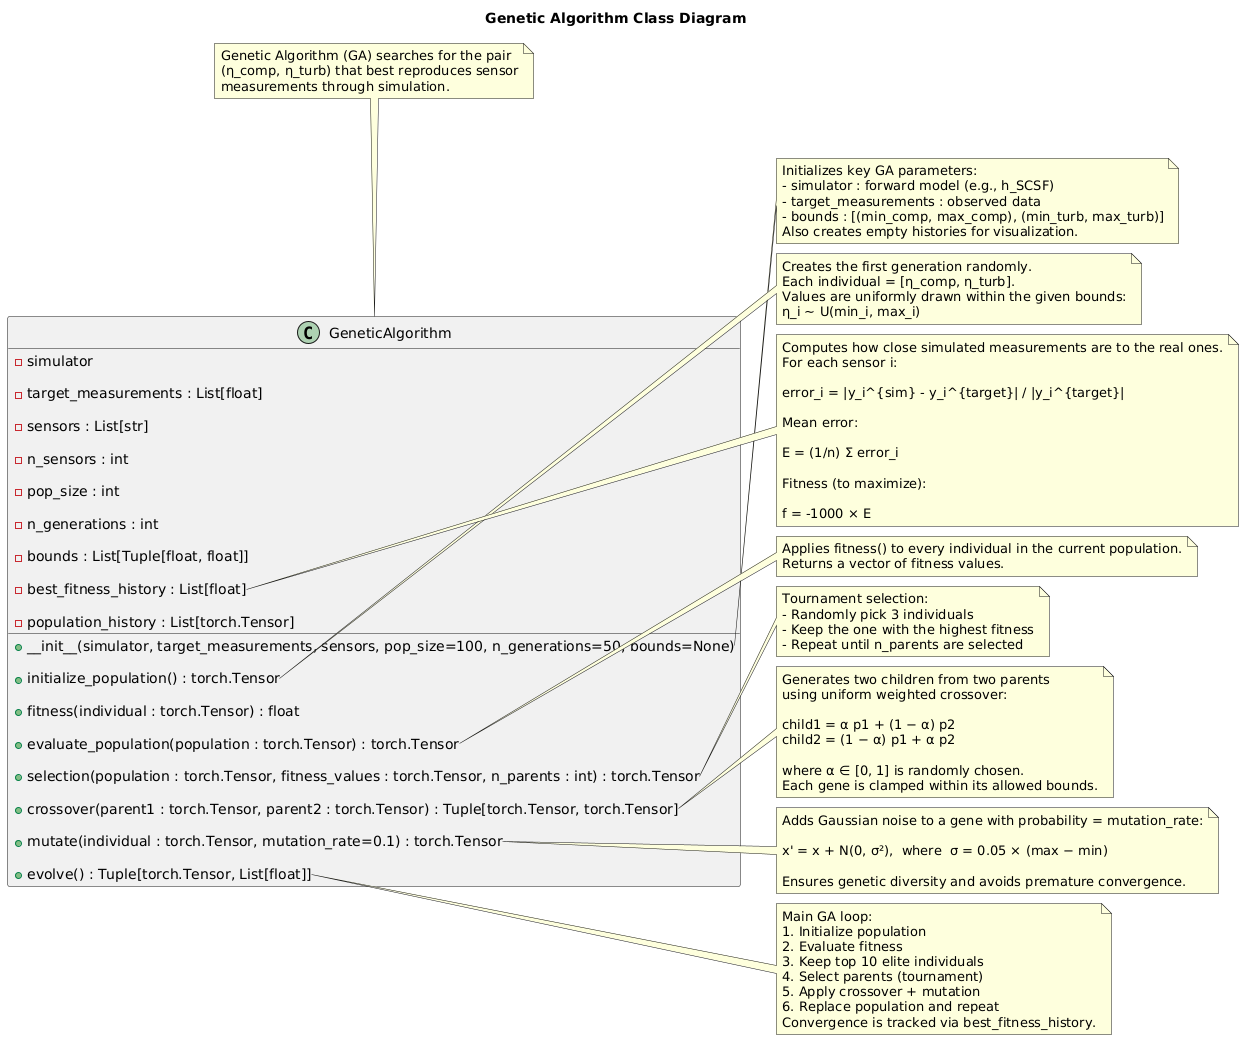

In [27]:
from IPython.display import Image, display

display(Image(filename='diagram_GA2.png'))


In [3]:
# Example: Estimate one measurement
true_traj = simulate_degradation_trajectory(speed='fast', waterwash='rare', size=2, seed=0)
true_traj =np.asarray(true_traj, dtype=float)[:,:2]
sensors = ['P3', 'T5']

# Get measurements for first time step
measured_series = list(h_SCSF(true_traj, S=sensors))
target_measurements = measured_series[0]  # First measurement

print(f"True health: {true_traj[0]}")
print(f"Target measurements: {target_measurements}")

import time
start_time = time.time()
# Create and run GA
ga = GeneticAlgorithm(
    simulator=h_SCSF,
    target_measurements=target_measurements,
    sensors=sensors,
    pop_size=100,
    n_generations=5
)

best_solution, fitness_history = ga.evolve()
print("end_time")
print ( time.time() - start_time )

print(f"\nEstimated health: [{best_solution[0].item():.4f}, {best_solution[1].item():.4f}]")
print(f"Error: {np.abs(np.array(true_traj[0]) - best_solution.cpu().numpy())}")

True health: [1.00882026 1.00200079]
Target measurements: [1.79516603e+06 1.43208210e+03]


/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(


Generation 0: Fitness = -3.07, eta_comp = 1.0104, eta_turb = 0.9730
end_time
57.154303789138794

Estimated health: [1.0088, 1.0020]
Error: [2.95302998e-05 7.12988339e-06]


---
The warning can happen because :
- initial population is very close to the true measurement, meaning some candidates produce extreme or unrealistic engine states?
- The estimated candidated are unrealistic (Seems to be more related to this issue)

**Error**

In [4]:
true_traj

array([[1.00882026, 1.00200079],
       [1.00872232, 1.00166389]])

In [4]:
import math

error_0 = abs(true_traj[0][0] - best_solution[0].item())  # eta_comp error
error_1 = abs(true_traj[0][1] - best_solution[1].item())  # eta_turb error

print("Error on eta_comp:", error_0)
print("Error on eta_turb:", error_1)


Error on eta_comp: 2.953029978458588e-05
Error on eta_turb: 7.1298833888011615e-06


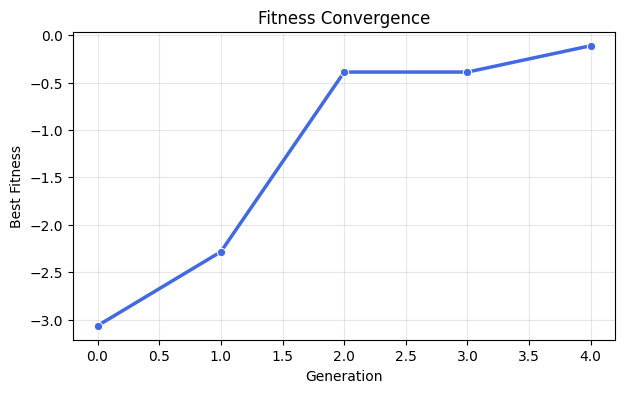

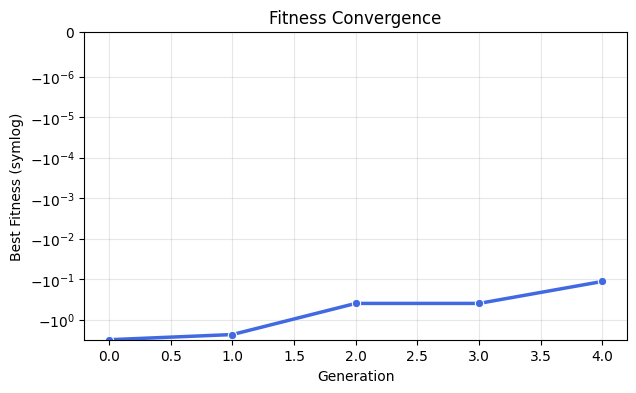

In [5]:
plot_convergence(ga)
# (Symmetric Log Scale)
plot_convergence_log(ga)

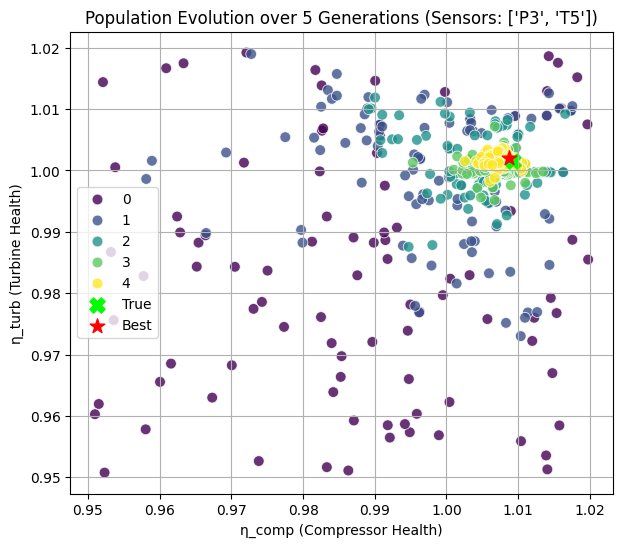

In [7]:
# Plot distribution of the population
plot_ga_seaborn(ga, best_solution, true_health=[1.0093, 1.0015])

Let us print measurements

True health: [1.00882026 1.00200079]
Target measurements: [1.79516603e+06 1.43208210e+03]


/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(


Generation 0: Fitness = -10.43, eta_comp = 0.9578, eta_turb = 0.9856
end_time
7.651859998703003

Estimated health: [1.0017, 1.0039]
Error: [0.0070872  0.00192478]
Error on eta_comp: 0.007087197078349039
Error on eta_turb: 0.0019247758630711598


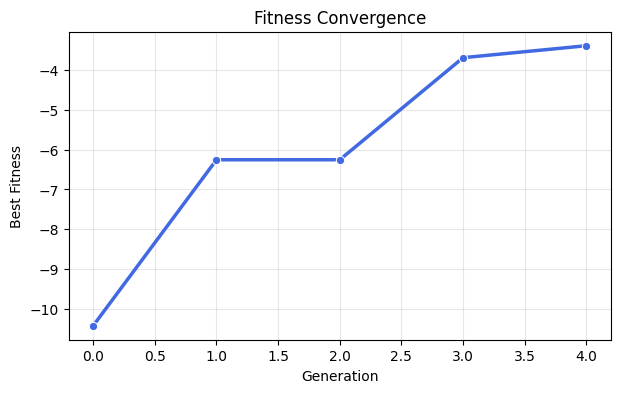

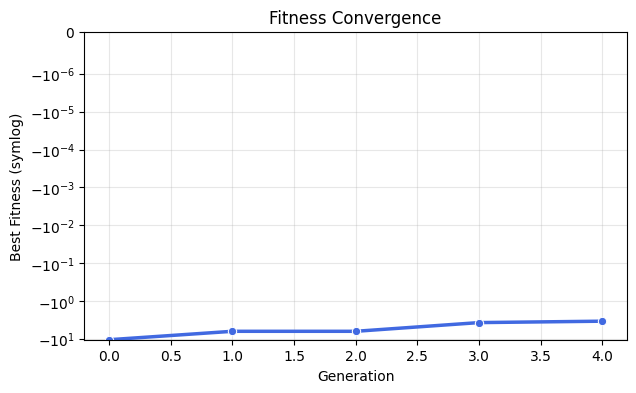

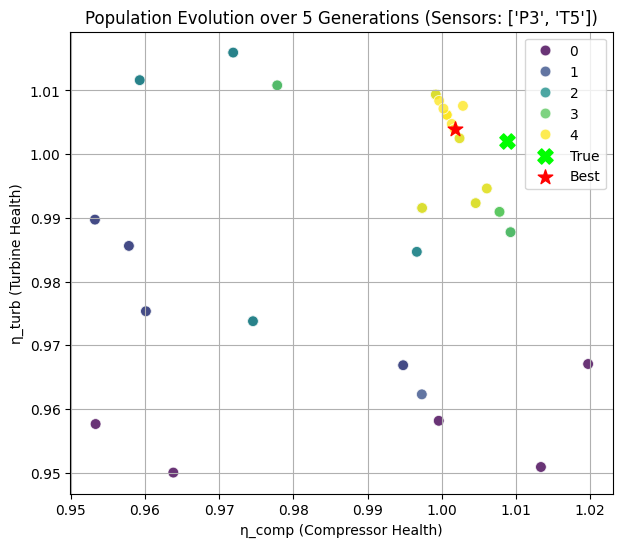

In [9]:
# Example: Estimate one measurement
true_traj = simulate_degradation_trajectory(speed='fast', waterwash='rare', size=2, seed=0)
#- take first 2 components
true_traj =np.asarray(true_traj, dtype=float)[:,:2]
sensors = ['P3', 'T5']

# Get measurements for first time step
measured_series = list(h_SCSF(true_traj, S=sensors))
target_measurements = measured_series[0]  # First measurement

print(f"True health: {true_traj[0]}")
print(f"Target measurements: {target_measurements}")

import time
start_time = time.time()
# Create and run GA
ga = GeneticAlgorithm(
    simulator=h_SCSF,
    target_measurements=target_measurements,
    sensors=sensors,
    pop_size=15,
    n_generations=5
)

best_solution, fitness_history = ga.evolve()
print("end_time")
print ( time.time() - start_time )

print(f"\nEstimated health: [{best_solution[0].item():.4f}, {best_solution[1].item():.4f}]")
print(f"Error: {np.abs(np.array(true_traj[0]) - best_solution.cpu().numpy())}")


#
import math

error_0 = abs(true_traj[0][0] - best_solution[0].item())  # eta_comp error
error_1 = abs(true_traj[0][1] - best_solution[1].item())  # eta_turb error

print("Error on eta_comp:", error_0)
print("Error on eta_turb:", error_1)

# plot convergence
plot_convergence(ga)
# Log scale
plot_convergence_log(ga)
#
# plot generations
plot_ga_seaborn(ga, best_solution, true_health=[1.0088202617298383, 1.002000786041836])

Some candidates are indeed  given unrealistics output

# Try with only one sensor

In [10]:
# Example: Estimate one measurement
true_traj = simulate_degradation_trajectory(speed='fast', waterwash='rare', size=2, seed=0)
#- take first 2 components
true_traj =np.asarray(true_traj, dtype=float)[:,:2]
sensors = ['P3']

# Get measurements for first time step
measured_series = list(h_SCSF(true_traj, S=sensors))
target_measurements = measured_series[0]  # First measurement

print(f"True health: {true_traj[0]}")
print(f"Target measurements: {target_measurements}")

import time
start_time = time.time()
# Create and run GA
ga = GeneticAlgorithm(
    simulator=h_SCSF,
    target_measurements=target_measurements,
    sensors=sensors,
    pop_size=100,
    n_generations=5
)

best_solution, fitness_history = ga.evolve()
print("end_time")
print ( time.time() - start_time )


print(f"\nEstimated health: [{best_solution[0].item():.4f}, {best_solution[1].item():.4f}]")
print(f"Error: {np.abs(np.array(true_traj[0]) - best_solution.cpu().numpy())}")


True health: [1.00882026 1.00200079]
Target measurements: [1795166.03048559]


/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(


Generation 0: Fitness = -0.07, eta_comp = 0.9726, eta_turb = 0.9530


/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid va

end_time
59.5395450592041

Estimated health: [0.9875, 0.9820]
Error: [0.02127459 0.01997159]


Error on eta_comp: 0.021274592651011393
Error on eta_turb: 0.01997158644161634


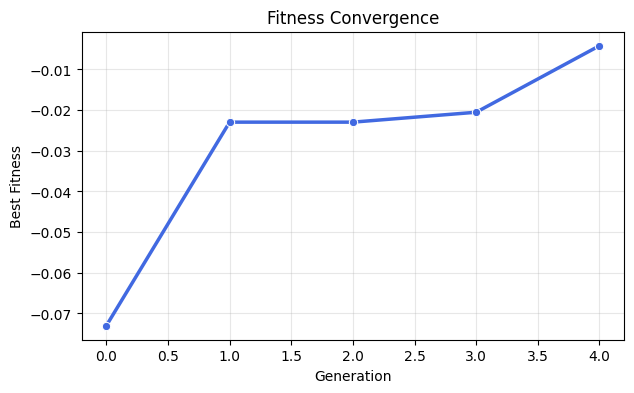

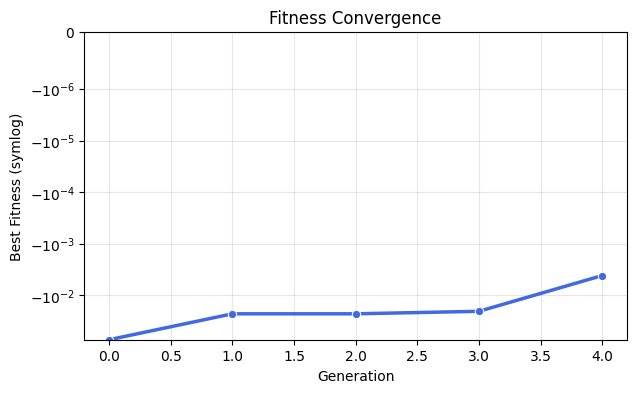

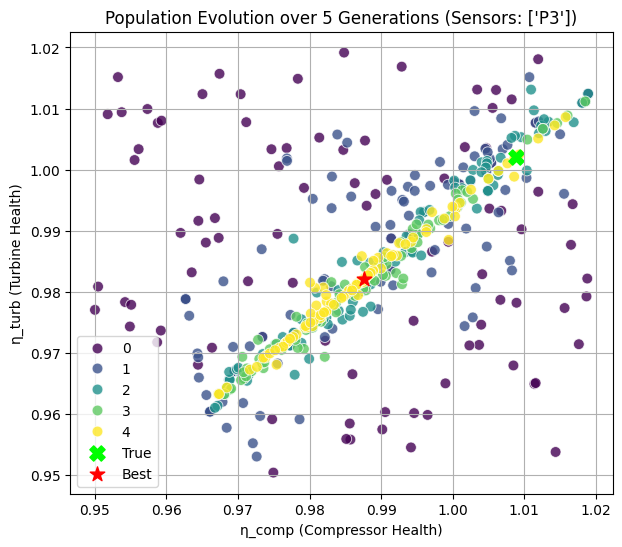

In [11]:


#
import math

error_0 = abs(true_traj[0][0] - best_solution[0].item())  # eta_comp error
error_1 = abs(true_traj[0][1] - best_solution[1].item())  # eta_turb error

print("Error on eta_comp:", error_0)
print("Error on eta_turb:", error_1)

# plot convergence
plot_convergence(ga)


plot_convergence_log(ga)
#
# plot generations
plot_ga_seaborn(ga, best_solution, true_health=[1.0088202617298383, 1.002000786041836])

**Note**
- The previous simulation is not always generating data inside bounds. so need to be fixed
- Same apply to the estimated measurements?

Error on eta_comp: 0.021274592651011393
Error on eta_turb: 0.01997158644161634


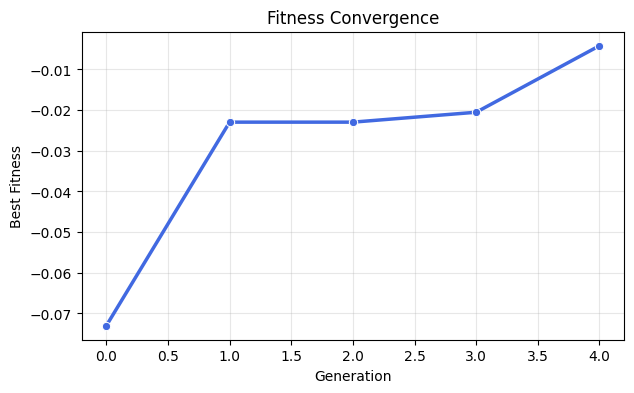

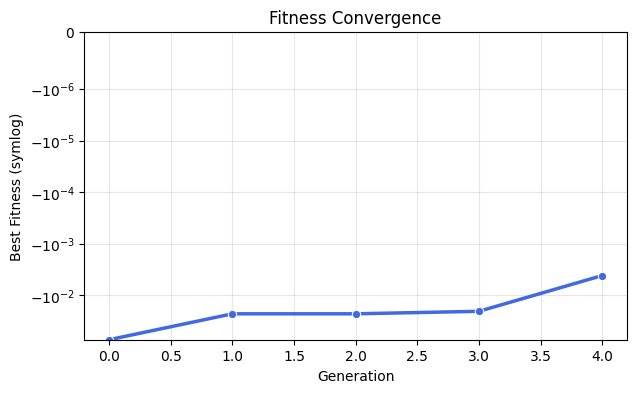

In [12]:
import math

error_0 = abs(true_traj[0][0] - best_solution[0].item())  # eta_comp error
error_1 = abs(true_traj[0][1] - best_solution[1].item())  # eta_turb error

print("Error on eta_comp:", error_0)
print("Error on eta_turb:", error_1)

# plot convergence
plot_convergence(ga)

plot_convergence_log(ga)

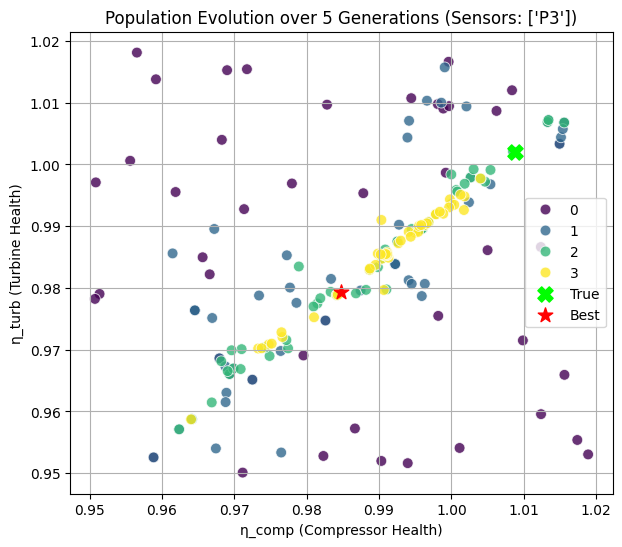

In [230]:
# plot generations
plot_ga_seaborn(ga, best_solution, true_health=[1.0088202617298383, 1.002000786041836])

# Parameterization + test with ( 1 ,2,3 ) measurements +fixed of outbounds
- One way to fixed outside bound value is to clamp the individual inside bound
- Another option could be by assigning a very bad fitness to that individual , assuming it will naturally disappear from the population in the next generations

The first on will be implemented

Test with 2 measurements

True health: [1.00882026 1.00200079]
Target measurements: [1.79516603e+06 1.43208210e+03]


/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(


Gen   0 | Best Fitness =   -3.106 | Genes = [1.0171111822128296, 1.0026406049728394]
Gen   5 | Best Fitness =   -0.148 | Genes = [1.0099399089813232, 1.0015394687652588]
Gen   9 | Best Fitness =   -0.024 | Genes = [1.0087552070617676, 1.0019856691360474]
simulated measurement : [1.79510205e+06 1.43216592e+03]

--- End of Evolution ---
Execution time: 108.69 s

Estimated health: η_comp=1.0089, η_turb=1.0020
True health:       η_comp=1.0088, η_turb=1.0020
Error on η_comp: 0.000048
Error on η_turb: 0.000014


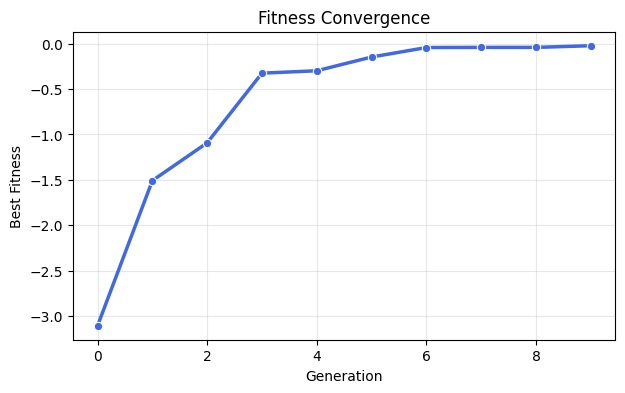

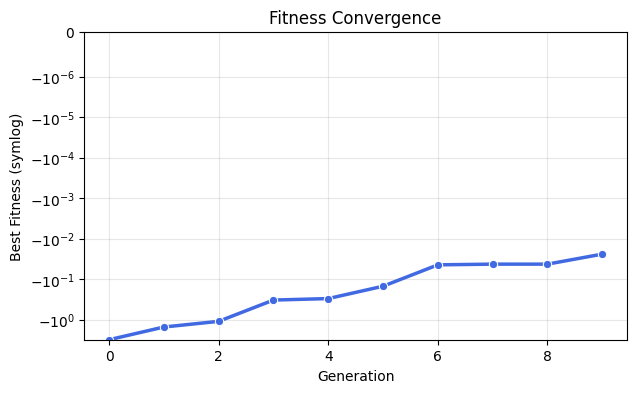

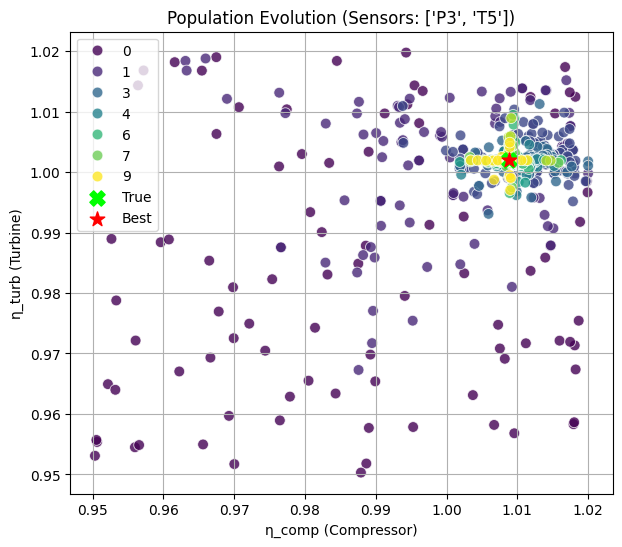

In [13]:

# ----------------------------------------------------------
# STEP 1 — Simulate True Health & Target Measurements
# ----------------------------------------------------------
true_traj = simulate_degradation_trajectory(speed='fast', waterwash='frequent', size=2, seed=0)
true_traj =np.asarray(true_traj, dtype=float)[:,:2]
sensors = ['P3', 'T5']

# Get simulated sensor measurements for first time step
measured_series = list(h_SCSF(true_traj, S=sensors))
target_measurements = measured_series[0]  # first sample

print(f"True health: {true_traj[0]}")
print(f"Target measurements: {target_measurements}")


# ----------------------------------------------------------
# STEP 2 — Create and Run the Genetic Algorithm
# ----------------------------------------------------------
start_time = time.time()

ga = GeneticAlgorithmv2(
    simulator=h_SCSF,
    target_measurements=target_measurements,
    sensors=sensors,
    n_genes=2,                 # two parameters: η_comp, η_turb
    pop_size=100,              # population size
    n_generations=10,          # number of generations
    bounds=[(0.95, 1.02), (0.95, 1.02)],
    mutation_rate=0.1,
    crossover_rate=0.9,
    tournament_size=3,
    n_elite=10,
    mutation_std_ratio=0.05
)

best_solution, fitness_history = ga.evolve(verbose_interval=5)

print("\n--- End of Evolution ---")
print(f"Execution time: {time.time() - start_time:.2f} s")

# ----------------------------------------------------------
# STEP 3 — Display Best Solution
# ----------------------------------------------------------
eta_comp_est, eta_turb_est = best_solution.cpu().numpy()
true_eta_comp, true_eta_turb = true_traj[0]

print(f"\nEstimated health: η_comp={eta_comp_est:.4f}, η_turb={eta_turb_est:.4f}")
print(f"True health:       η_comp={true_eta_comp:.4f}, η_turb={true_eta_turb:.4f}")

# Compute absolute errors
error_comp = abs(true_eta_comp - eta_comp_est)
error_turb = abs(true_eta_turb - eta_turb_est)

print(f"Error on η_comp: {error_comp:.6f}")
print(f"Error on η_turb: {error_turb:.6f}")


# ----------------------------------------------------------
# STEP 4 — Visualizations
# ----------------------------------------------------------
plot_convergence(ga)
plot_convergence_log(ga)
plot_ga_population(ga, best_solution, true_health=[true_eta_comp, true_eta_turb])


# Try with 1 measurement

Only with T5

True health: [1.00882026 1.00200079]
Target measurements: [1432.08210265]


/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(


Gen   0 | Best Fitness =   -1.070 | Genes = [0.9701804518699646, 1.0091111660003662]
Gen   5 | Best Fitness =   -0.006 | Genes = [0.9622403383255005, 1.015221357345581]
Gen   9 | Best Fitness =   -0.000 | Genes = [0.968217670917511, 1.013497233390808]
simulated measurement : [1432.07922867]

--- End of Evolution ---
Execution time: 109.37 s

Estimated health: η_comp=0.9671, η_turb=1.0138
True health:       η_comp=1.0088, η_turb=1.0020
Error on η_comp: 0.041757
Error on η_turb: 0.011827


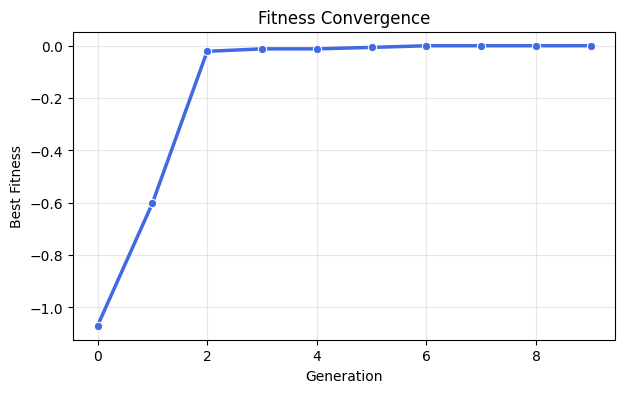

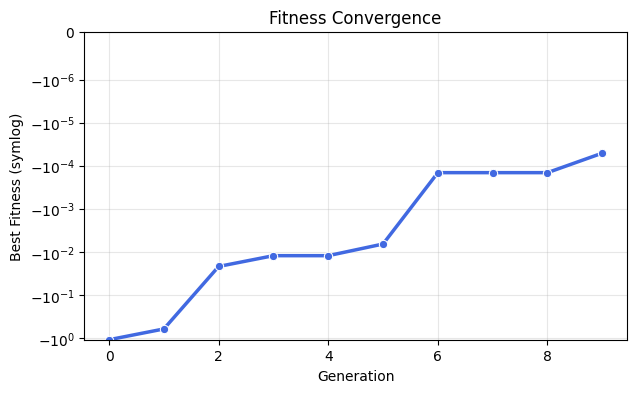

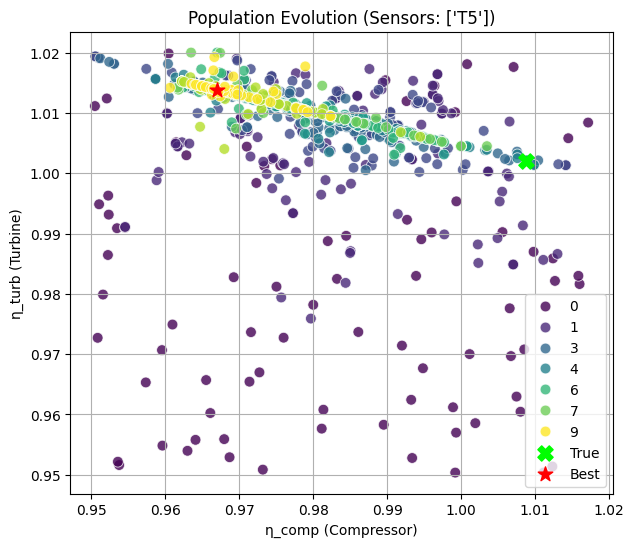

In [14]:
# ==========================================================
# Example: Estimate one measurement using Genetic Algorithm
# ==========================================================
import time
import numpy as np

# ----------------------------------------------------------
# STEP 1 - Simulate True Health & Target Measurements
# ----------------------------------------------------------
true_traj = simulate_degradation_trajectory(speed='fast', waterwash='rare', size=2, seed=0)
true_traj =np.asarray(true_traj, dtype=float)[:,:2]
sensors = ['T5']

# Get simulated sensor measurements for first time step
measured_series = list(h_SCSF(true_traj, S=sensors))
target_measurements = measured_series[0]  # first sample

print(f"True health: {true_traj[0]}")
print(f"Target measurements: {target_measurements}")


# ----------------------------------------------------------
# STEP 2 — Create and Run the Genetic Algorithm
# ----------------------------------------------------------
start_time = time.time()

ga = GeneticAlgorithmv2(
    simulator=h_SCSF,
    target_measurements=target_measurements,
    sensors=sensors,
    n_genes=2,                 # two parameters: η_comp, η_turb
    pop_size=100,              # population size
    n_generations=10,          # number of generations
    bounds=[(0.95, 1.02), (0.95, 1.02)],
    mutation_rate=0.1,
    crossover_rate=0.9,
    tournament_size=3,
    n_elite=10,
    mutation_std_ratio=0.05
)

best_solution, fitness_history = ga.evolve(verbose_interval=5)

print("\n--- End of Evolution ---")
print(f"Execution time: {time.time() - start_time:.2f} s")

# ----------------------------------------------------------
# STEP 3 - Display Best Solution
# ----------------------------------------------------------
eta_comp_est, eta_turb_est = best_solution.cpu().numpy()
true_eta_comp, true_eta_turb = true_traj[0]

print(f"\nEstimated health: η_comp={eta_comp_est:.4f}, η_turb={eta_turb_est:.4f}")
print(f"True health:       η_comp={true_eta_comp:.4f}, η_turb={true_eta_turb:.4f}")

# Compute absolute errors
error_comp = abs(true_eta_comp - eta_comp_est)
error_turb = abs(true_eta_turb - eta_turb_est)

print(f"Error on η_comp: {error_comp:.6f}")
print(f"Error on η_turb: {error_turb:.6f}")


# ----------------------------------------------------------
# STEP 4 — Visualizations
# ----------------------------------------------------------
plot_convergence(ga)
plot_convergence_log(ga)
plot_ga_population(ga, best_solution, true_health=[true_eta_comp, true_eta_turb])


- Although the aldorithm is working for some random individual,
- we will notice we still encounter some issue related to the bound
- There is a need to update the way GA is contructed
-  This is with T5

Only with P3

True health: [1.00882026 1.00200079]
Target measurements: [1795166.03048559]


/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid va

Gen   0 | Best Fitness =   -0.525 | Genes = [0.9776964783668518, 0.971072256565094]


/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid va

Gen   5 | Best Fitness =   -0.001 | Genes = [0.9944729804992676, 0.9885542392730713]
Gen   9 | Best Fitness =   -0.000 | Genes = [0.9887638092041016, 0.9831849932670593]
simulated measurement : [1795166.00376299]

--- End of Evolution ---
Execution time: 112.17 s

Estimated health: η_comp=0.9888, η_turb=0.9832
True health:       η_comp=1.0088, η_turb=1.0020
Error on η_comp: 0.020056
Error on η_turb: 0.018816


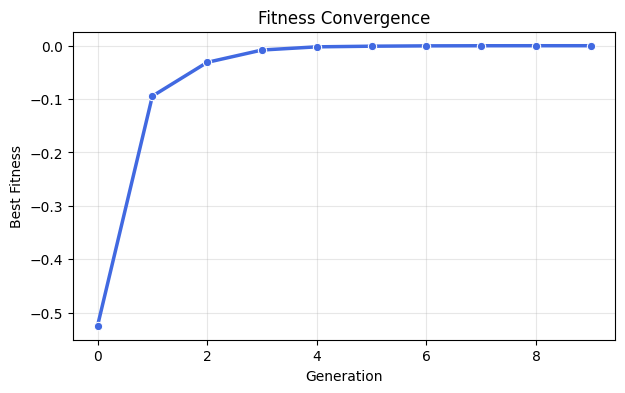

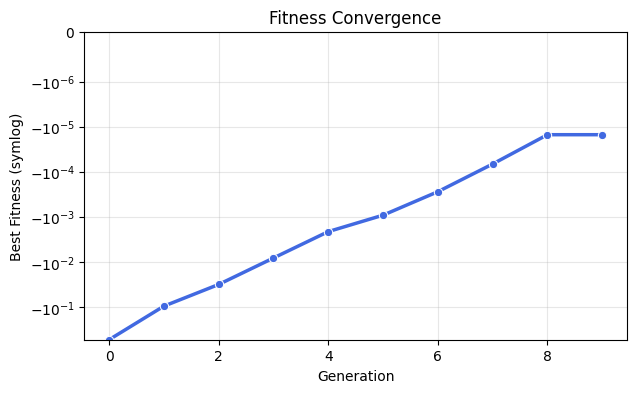

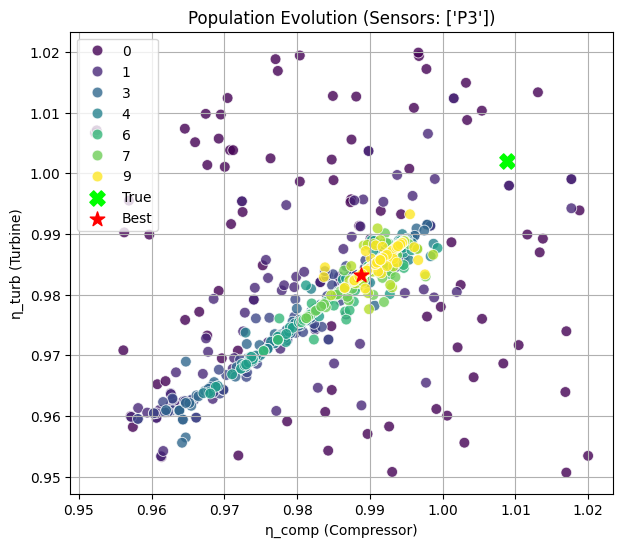

In [16]:

# ----------------------------------------------------------
# STEP 1 - Simulate True Health & Target Measurements
# ----------------------------------------------------------
true_traj = simulate_degradation_trajectory(speed='fast', waterwash='rare', size=2, seed=0)
true_traj =np.asarray(true_traj, dtype=float)[:,:2]
sensors = ['P3']

# Get simulated sensor measurements for first time step
measured_series = list(h_SCSF(true_traj, S=sensors))
target_measurements = measured_series[0]  # first sample

print(f"True health: {true_traj[0]}")
print(f"Target measurements: {target_measurements}")


# ----------------------------------------------------------
# STEP 2 — Create and Run the Genetic Algorithm
# ----------------------------------------------------------
start_time = time.time()

ga = GeneticAlgorithmv2(
    simulator=h_SCSF,
    target_measurements=target_measurements,
    sensors=sensors,
    n_genes=2,                 # two parameters: η_comp, η_turb
    pop_size=100,              # population size
    n_generations=10,          # number of generations
    bounds=[(0.95, 1.02), (0.95, 1.02)],
    mutation_rate=0.1,
    crossover_rate=0.9,
    tournament_size=3,
    n_elite=10,
    mutation_std_ratio=0.05
)

best_solution, fitness_history = ga.evolve(verbose_interval=5)

print("\n--- End of Evolution ---")
print(f"Execution time: {time.time() - start_time:.2f} s")

# ----------------------------------------------------------
# STEP 3 - Display Best Solution
# ----------------------------------------------------------
eta_comp_est, eta_turb_est = best_solution.cpu().numpy()
true_eta_comp, true_eta_turb = true_traj[0]

print(f"\nEstimated health: η_comp={eta_comp_est:.4f}, η_turb={eta_turb_est:.4f}")
print(f"True health:       η_comp={true_eta_comp:.4f}, η_turb={true_eta_turb:.4f}")

# Compute absolute errors
error_comp = abs(true_eta_comp - eta_comp_est)
error_turb = abs(true_eta_turb - eta_turb_est)

print(f"Error on η_comp: {error_comp:.6f}")
print(f"Error on η_turb: {error_turb:.6f}")


# ----------------------------------------------------------
# STEP 4 — Visualizations
# ----------------------------------------------------------
plot_convergence(ga)
plot_convergence_log(ga)
plot_ga_population(ga, best_solution, true_health=[true_eta_comp, true_eta_turb])


## Let us try by taking as initial value a point not close to the initial measurement
- We will generate 100 points
- Take the 55th point then the 10th point for the simualtion
- Let us do that P3 and T5

Test with  the 10th flight

/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(


True health: [1.00882026 1.00200079]
Target measurements: [1.79487724e+06 1.44407315e+03]


/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid va

Gen   0 | Best Fitness =   -5.732 | Genes = [0.965323805809021, 0.9821566343307495]
Gen   5 | Best Fitness =   -0.142 | Genes = [1.0047467947006226, 0.9985213875770569]
Gen  10 | Best Fitness =   -0.017 | Genes = [1.011892318725586, 0.998383641242981]
Gen  15 | Best Fitness =   -0.000 | Genes = [1.004766821861267, 0.9984123110771179]
Gen  19 | Best Fitness =   -0.000 | Genes = [1.0047651529312134, 0.9984117150306702]
simulated measurement : [1.79487721e+06 1.44407339e+03]

--- End of Evolution ---
Execution time: 237.27 s

Estimated health: η_comp=1.0048, η_turb=0.9984
True health:       η_comp=1.0088, η_turb=1.0020
Error on η_comp: 0.004055
Error on η_turb: 0.003589


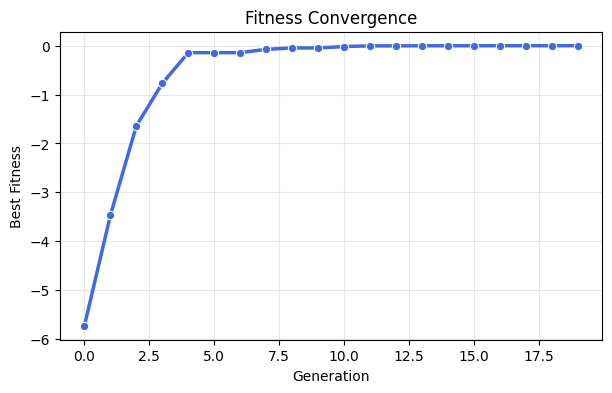

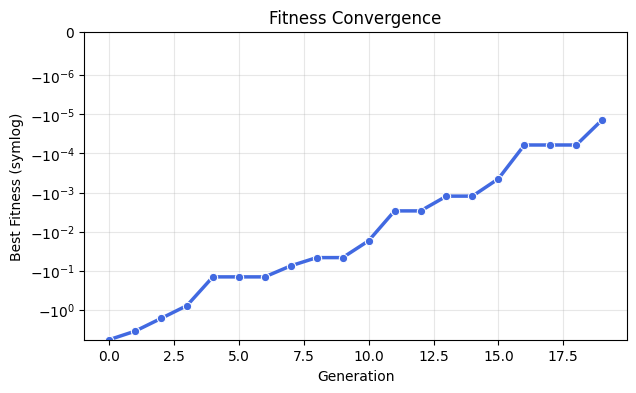

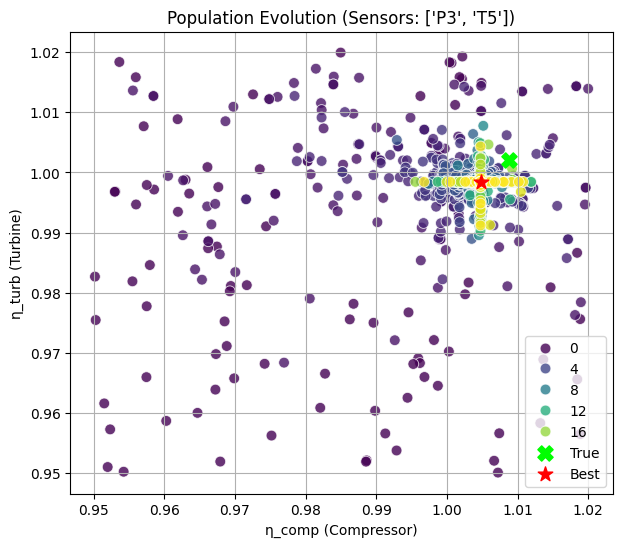

In [17]:

# ----------------------------------------------------------
# STEP 1 - Simulate True Health & Target Measurements
# ----------------------------------------------------------
true_traj = simulate_degradation_trajectory(speed='fast', waterwash='rare', size=100, seed=0)
true_traj =np.asarray(true_traj, dtype=float)[:,:2]

sensors = ['P3', 'T5']

# Get simulated sensor measurements for first time step
measured_series = list(h_SCSF(true_traj, S=sensors))
target_measurements = measured_series[10]  # 10th sample

print(f"True health: {true_traj[0]}")
print(f"Target measurements: {target_measurements}")


# ----------------------------------------------------------
# STEP 2 — Create and Run the Genetic Algorithm
# ----------------------------------------------------------
start_time = time.time()

ga = GeneticAlgorithmv2(
    simulator=h_SCSF,
    target_measurements=target_measurements,
    sensors=sensors,
    n_genes=2,                 # two parameters: η_comp, η_turb
    pop_size=100,              # population size
    n_generations=20,          # number of generations
    bounds=[(0.95, 1.02), (0.95, 1.02)],
    mutation_rate=0.1,
    crossover_rate=0.9,
    tournament_size=3,
    n_elite=10,
    mutation_std_ratio=0.05
)

best_solution, fitness_history = ga.evolve(verbose_interval=5)

print("\n--- End of Evolution ---")
print(f"Execution time: {time.time() - start_time:.2f} s")

# ----------------------------------------------------------
# STEP 3 - Display Best Solution
# ----------------------------------------------------------
eta_comp_est, eta_turb_est = best_solution.cpu().numpy()
true_eta_comp, true_eta_turb = true_traj[0]

print(f"\nEstimated health: η_comp={eta_comp_est:.4f}, η_turb={eta_turb_est:.4f}")
print(f"True health:       η_comp={true_eta_comp:.4f}, η_turb={true_eta_turb:.4f}")

# Compute absolute errors
error_comp = abs(true_eta_comp - eta_comp_est)
error_turb = abs(true_eta_turb - eta_turb_est)

print(f"Error on η_comp: {error_comp:.6f}")
print(f"Error on η_turb: {error_turb:.6f}")


# ----------------------------------------------------------
# STEP 4 — Visualizations
# ----------------------------------------------------------
plot_convergence(ga)
plot_convergence_log(ga)
plot_ga_population(ga, best_solution, true_health=[true_eta_comp, true_eta_turb])

Test with the 55th flight

/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(


True health: [1.00882026 1.00200079]
Target measurements: [1.79676102e+06 1.50639302e+03]
Gen   0 | Best Fitness =   -1.220 | Genes = [0.9665104150772095, 0.9787836074829102]
Gen   5 | Best Fitness =   -0.065 | Genes = [0.9856767654418945, 0.9798031449317932]
Gen  10 | Best Fitness =   -0.004 | Genes = [0.9863401651382446, 0.9797644019126892]
Gen  15 | Best Fitness =   -0.000 | Genes = [0.986309289932251, 0.9797731637954712]
Gen  19 | Best Fitness =   -0.000 | Genes = [0.9863094091415405, 0.9797731637954712]
simulated measurement : [1.79676086e+06 1.50639337e+03]

--- End of Evolution ---
Execution time: 272.14 s

Estimated health: η_comp=0.9863, η_turb=0.9798
True health:       η_comp=1.0088, η_turb=1.0020
Error on η_comp: 0.022511
Error on η_turb: 0.022228


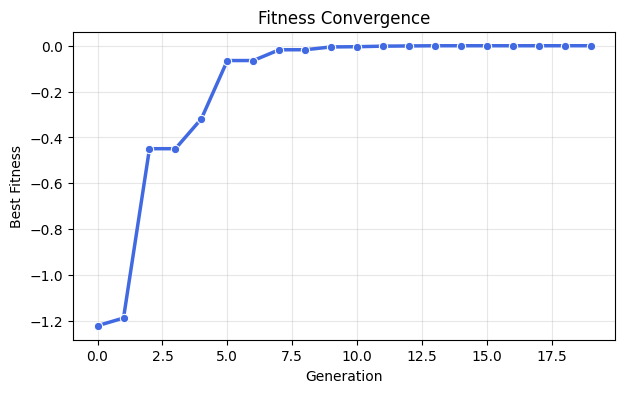

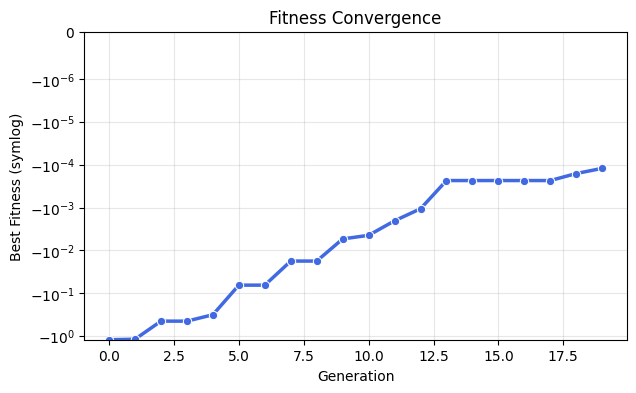

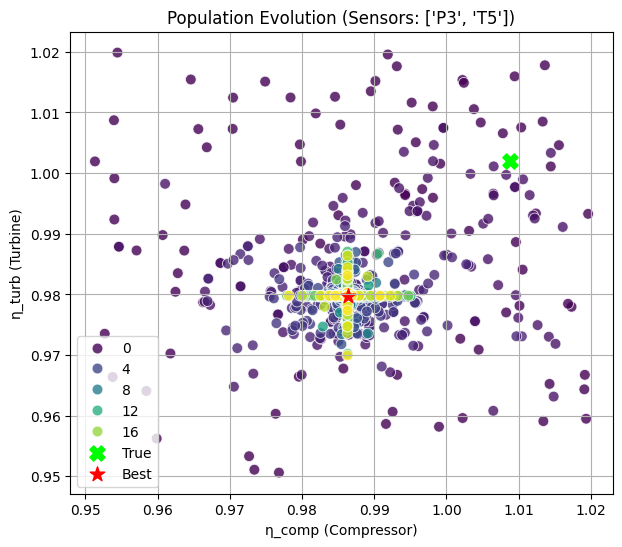

In [18]:
# ----------------------------------------------------------
# STEP 1 - Simulate True Health & Target Measurements
# ----------------------------------------------------------
true_traj = simulate_degradation_trajectory(speed='fast', waterwash='rare', size=100, seed=0)
true_traj =np.asarray(true_traj, dtype=float)[:,:2]

sensors = ['P3', 'T5']

# Get simulated sensor measurements for first time step
measured_series = list(h_SCSF(true_traj, S=sensors))
target_measurements = measured_series[55]  # 55th sample

print(f"True health: {true_traj[0]}")
print(f"Target measurements: {target_measurements}")


# ----------------------------------------------------------
# STEP 2 — Create and Run the Genetic Algorithm
# ----------------------------------------------------------
start_time = time.time()

ga = GeneticAlgorithmv2(
    simulator=h_SCSF,
    target_measurements=target_measurements,
    sensors=sensors,
    n_genes=2,                 # two parameters: η_comp, η_turb
    pop_size=100,              # population size
    n_generations=20,          # number of generations
    bounds=[(0.95, 1.02), (0.95, 1.02)],
    mutation_rate=0.1,
    crossover_rate=0.9,
    tournament_size=3,
    n_elite=10,
    mutation_std_ratio=0.05
)

best_solution, fitness_history = ga.evolve(verbose_interval=5)

print("\n--- End of Evolution ---")
print(f"Execution time: {time.time() - start_time:.2f} s")

# ----------------------------------------------------------
# STEP 3 - Display Best Solution
# ----------------------------------------------------------
eta_comp_est, eta_turb_est = best_solution.cpu().numpy()
true_eta_comp, true_eta_turb = true_traj[0]

print(f"\nEstimated health: η_comp={eta_comp_est:.4f}, η_turb={eta_turb_est:.4f}")
print(f"True health:       η_comp={true_eta_comp:.4f}, η_turb={true_eta_turb:.4f}")

# Compute absolute errors
error_comp = abs(true_eta_comp - eta_comp_est)
error_turb = abs(true_eta_turb - eta_turb_est)

print(f"Error on η_comp: {error_comp:.6f}")
print(f"Error on η_turb: {error_turb:.6f}")


# ----------------------------------------------------------
# STEP 4 — Visualizations
# ----------------------------------------------------------
plot_convergence(ga)
plot_convergence_log(ga)
plot_ga_population(ga, best_solution, true_health=[true_eta_comp, true_eta_turb])


Source of warning ?

In [19]:
true_traj = simulate_degradation_trajectory(speed='fast', waterwash='rare', size=100, seed=0)
true_traj =np.asarray(true_traj, dtype=float)[:,:2]

sensors = ['P3', 'T5']

# Get simulated sensor measurements for first time step
measured_series = list(h_SCSF(true_traj, S=sensors))
target_measurements = measured_series[55]  # 55th sample

/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(


**It seems like the "error" is also encountered from the way the simulator is being generated**


### Estimate 3 components (comp, turb, comb) with GA

- We did this with W3R but we shouldn't.   Consider it as an experiemnt
- For the rest of the simulation, we will use wf (airflow) instead

In [20]:
# ----------------------------------------------------------
# STEP 1 - Simulate True Health & Target Measurements
# ----------------------------------------------------------
true_traj = simulate_degradation_trajectory(speed='fast', waterwash='rare', size=100, seed=0)
# true_traj =np.asarray(true_traj, dtype=float)[:,:2]

sensors = ['P3', 'T5', 'W3R']

# Get simulated sensor measurements for first time step
measured_series = list(h_SCSF(true_traj, S=sensors))
target_measurements = measured_series[10]  # 55th sample

print(f"True health: {true_traj[0]}")
print(f"Target measurements: {target_measurements}")


# ----------------------------------------------------------
# STEP 2 — Create and Run the Genetic Algorithm
# ----------------------------------------------------------
start_time = time.time()

ga = GeneticAlgorithmv2(
    simulator=h_SCSF,
    target_measurements=target_measurements,
    sensors=sensors,
    n_genes=3,                 # two parameters: η_comp, η_turb
    pop_size=100,              # population size
    n_generations=20,          # number of generations
    bounds=[(0.95, 1.02), (0.95, 1.02), (0.95, 1.02)],
    mutation_rate=0.1,
    crossover_rate=0.9,
    tournament_size=3,
    n_elite=10,
    mutation_std_ratio=0.05
)

best_solution, fitness_history = ga.evolve(verbose_interval=5)

print("\n--- End of Evolution ---")
print(f"Execution time: {time.time() - start_time:.2f} s")


/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(


True health: [1.0088202617298383, 1.002000786041836, 1.0048936899205287]
Target measurements: [1.79246835e+06 1.44332123e+03 3.00000000e+00]


/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(


Gen   0 | Best Fitness =   -2.598 | Genes = [0.9769560098648071, 0.9999071359634399, 0.9722133874893188]


/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(


Gen   5 | Best Fitness =   -0.112 | Genes = [0.9975224733352661, 1.0028674602508545, 0.993928074836731]
Gen  10 | Best Fitness =   -0.008 | Genes = [0.9908239841461182, 1.0058202743530273, 0.988355278968811]
Gen  15 | Best Fitness =   -0.002 | Genes = [0.9904497861862183, 1.0060124397277832, 0.9880231618881226]
Gen  19 | Best Fitness =   -0.002 | Genes = [0.9903749227523804, 1.006051778793335, 0.9879555702209473]
simulated measurement : [1.79246913e+06 1.44331288e+03 3.00000000e+00]

--- End of Evolution ---
Execution time: 243.02 s



Estimated health: η_comp=0.9904, η_turb=1.0061, η_comb=0.9880
True health:       η_comp=1.0088, η_turb=1.0020, η_comb=1.0049
Error on η_comp: 0.018445
Error on η_turb: 0.004051
Error on η_turb: 0.004051


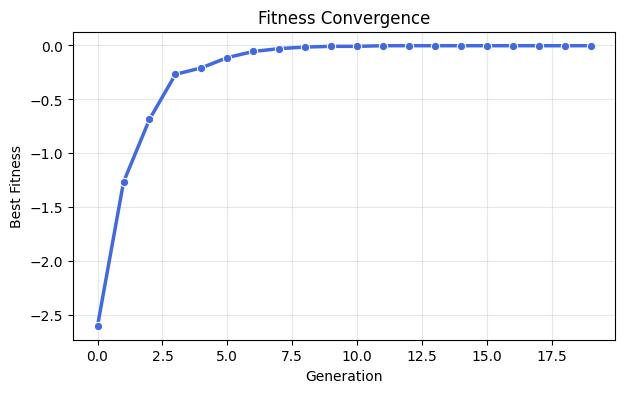

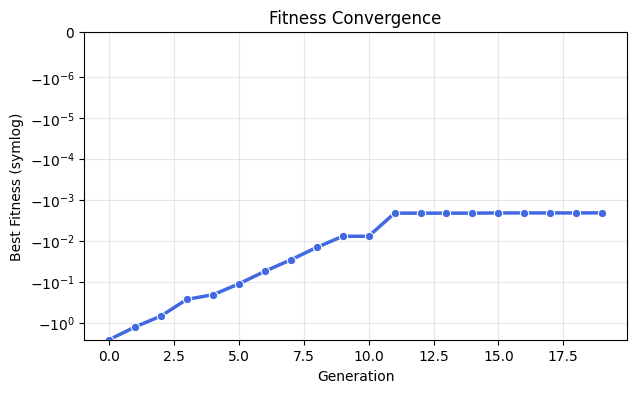

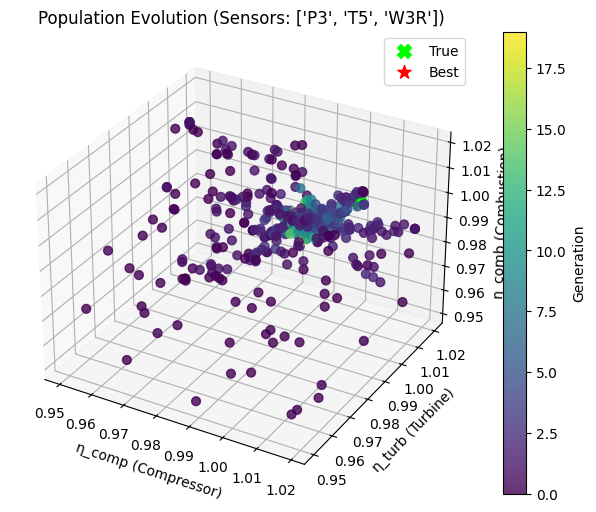

In [21]:
# ----------------------------------------------------------
# STEP 3 - Display Best Solution
# ----------------------------------------------------------
eta_comp_est, eta_turb_est,  eta_comb_est = best_solution.cpu().numpy()
true_eta_comp, true_eta_turb, true_eta_comb = true_traj[0]

print(f"\nEstimated health: η_comp={eta_comp_est:.4f}, η_turb={eta_turb_est:.4f}, η_comb={eta_comb_est:.4f}")
print(f"True health:       η_comp={true_eta_comp:.4f}, η_turb={true_eta_turb:.4f}, η_comb={true_eta_comb:.4f}")

# Compute absolute errors
error_comp = abs(true_eta_comp - eta_comp_est)
error_turb = abs(true_eta_turb - eta_turb_est)
error_comb = abs(true_eta_turb - eta_turb_est)

print(f"Error on η_comp: {error_comp:.6f}")
print(f"Error on η_turb: {error_turb:.6f}")
print(f"Error on η_turb: {error_comb:.6f}")


# ----------------------------------------------------------
# STEP 4 — Visualizations
# ----------------------------------------------------------
plot_convergence(ga)
plot_convergence_log(ga)
plot_ga_population(ga, best_solution, true_health=[true_eta_comp, true_eta_turb,  true_eta_comb])


### Update plot to 3D version

In [22]:
plot_ga_population_3d(ga, best_solution, true_health=[true_eta_comp, true_eta_turb,  true_eta_comb])

### Estimate 3 components (comp, turb, comb) with GA and Check if true measuremnts match with estimated measurement 


We use wf instead of W3R

In [23]:
# ----------------------------------------------------------
# STEP 1 - Simulate True Health & Target Measurements
# ----------------------------------------------------------
true_traj = simulate_degradation_trajectory(speed='fast', waterwash='rare', size=100, seed=0)
# true_traj =np.asarray(true_traj, dtype=float)[:,:2]

sensors = ['P3', 'T5', 'Wf']

# Get simulated sensor measurements for first time step
measured_series = list(h_SCSF(true_traj, S=sensors))
target_measurements = measured_series[10]  # 55th sample

print(f"True health: {true_traj[0]}")
print(f"Target measurements: {target_measurements}")


# ----------------------------------------------------------
# STEP 2 — Create and Run the Genetic Algorithm
# ----------------------------------------------------------
start_time = time.time()

ga = GeneticAlgorithmv2(
    simulator=h_SCSF,
    target_measurements=target_measurements,
    sensors=sensors,
    n_genes=3,                 # two parameters: η_comp, η_turb
    pop_size=100,              # population size
    n_generations=20,          # number of generations
    bounds=[(0.95, 1.02), (0.95, 1.02), (0.95, 1.02)],
    mutation_rate=0.1,
    crossover_rate=0.9,
    tournament_size=3,
    n_elite=10,
    mutation_std_ratio=0.05
)

best_solution, fitness_history = ga.evolve(verbose_interval=5)

print("\n--- End of Evolution ---")
print(f"Execution time: {time.time() - start_time:.2f} s")


/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning:

invalid value encountered in sqrt

/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning:

invalid value encountered in sqrt

/home/ensai/Documents/dataviz-course/SDSPROJECT/ENSAI/SAFRAN_ENSAI_2025/performancemodel_ENSAI/src/performancemodel/turboreactors.py:532: RuntimeWarning:

invalid value encountered in sqrt



True health: [1.0088202617298383, 1.002000786041836, 1.0048936899205287]
Target measurements: [1.79246835e+06 1.44332123e+03 1.38101346e+00]
Gen   0 | Best Fitness =   -2.888 | Genes = [0.9719928503036499, 0.9843307137489319, 1.0135796070098877]
Gen   5 | Best Fitness =   -0.486 | Genes = [0.9884681701660156, 1.0065221786499023, 0.9864946007728577]
Gen  10 | Best Fitness =   -0.344 | Genes = [0.9932031035423279, 1.0040987730026245, 0.9907938838005066]
Gen  15 | Best Fitness =   -0.314 | Genes = [0.9890320897102356, 1.0042142868041992, 0.9906079173088074]
Gen  19 | Best Fitness =   -0.314 | Genes = [0.9942667484283447, 1.0041505098342896, 0.9907119274139404]
simulated measurement : [1.79401327e+06 1.44341836e+03 1.38099520e+00]

--- End of Evolution ---
Execution time: 212.98 s



Estimated health: η_comp=0.9943, η_turb=1.0042, η_comb=0.9907
True health:       η_comp=1.0088, η_turb=1.0020, η_comb=1.0049
Error on η_comp: 0.014554
Error on η_turb: 0.002150
Error on η_turb: 0.002150


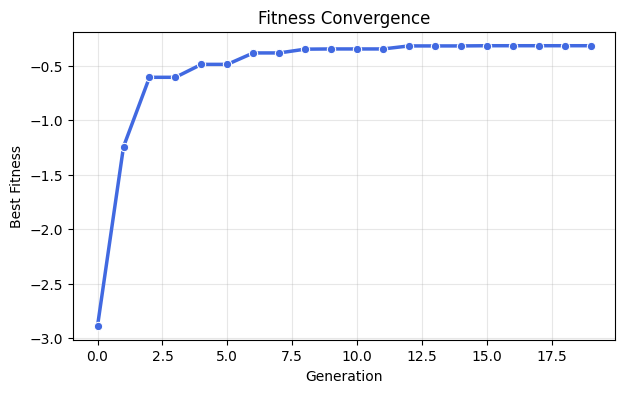

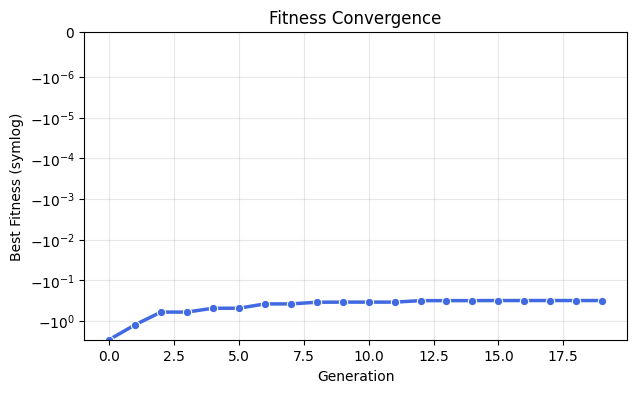

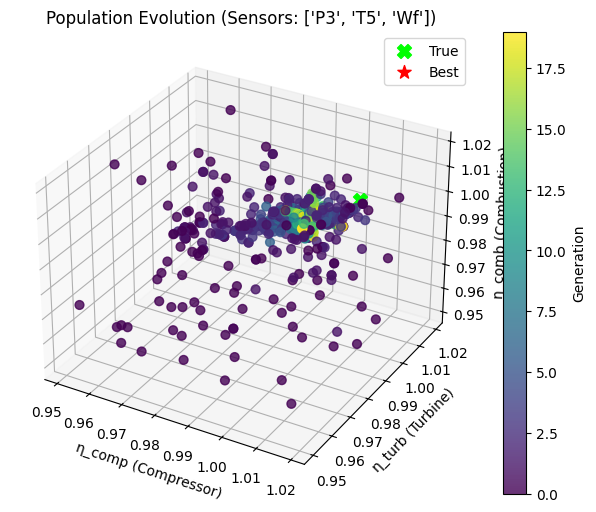

In [24]:
# ----------------------------------------------------------
# STEP 3 - Display Best Solution
# ----------------------------------------------------------

eta_comp_est, eta_turb_est,  eta_comb_est = best_solution.cpu().numpy()
true_eta_comp, true_eta_turb, true_eta_comb = true_traj[0]

print(f"\nEstimated health: η_comp={eta_comp_est:.4f}, η_turb={eta_turb_est:.4f}, η_comb={eta_comb_est:.4f}")
print(f"True health:       η_comp={true_eta_comp:.4f}, η_turb={true_eta_turb:.4f}, η_comb={true_eta_comb:.4f}")

# Compute absolute errors
error_comp = abs(true_eta_comp - eta_comp_est)
error_turb = abs(true_eta_turb - eta_turb_est)
error_comb = abs(true_eta_turb - eta_turb_est)

print(f"Error on η_comp: {error_comp:.6f}")
print(f"Error on η_turb: {error_turb:.6f}")
print(f"Error on η_turb: {error_comb:.6f}")


# ----------------------------------------------------------
# STEP 4 — Visualizations
# ----------------------------------------------------------
plot_convergence(ga)
plot_convergence_log(ga)
plot_ga_population(ga, best_solution, true_health=[true_eta_comp, true_eta_turb,  true_eta_comb])


**Note**  : 
- Target measurements: [1.79246835e+06 1.44332123e+03 1.38101346e+00]
- simulated measurement : [1.79247209e+06 1.44333237e+03 1.38077830e+00] 

Since target measurements almost match True measurments, we can conclude that individuals are stuck in the local minimum


In [25]:
print ("Compressor")
print ((1.79246835e+06-1.79247209e+06)/1.79246835e+06 )
print ("\ncombustion")
print((1.44332123e+03  -1.44333237e+03 )/1.44332123e+03 )
print("\nTurbine")
print ((1.38101346e+0-1.38077830e+00)/1.38101346e+0)

Compressor
-2.08650824991732e-06

combustion
-7.718309527026454e-06

Turbine
0.00017028074440338982


 ***DANGER*** : This is not a way to check if the solution get stuck in local minima. An update will be done in the next version 
  Maybe the mutation step  is very low?

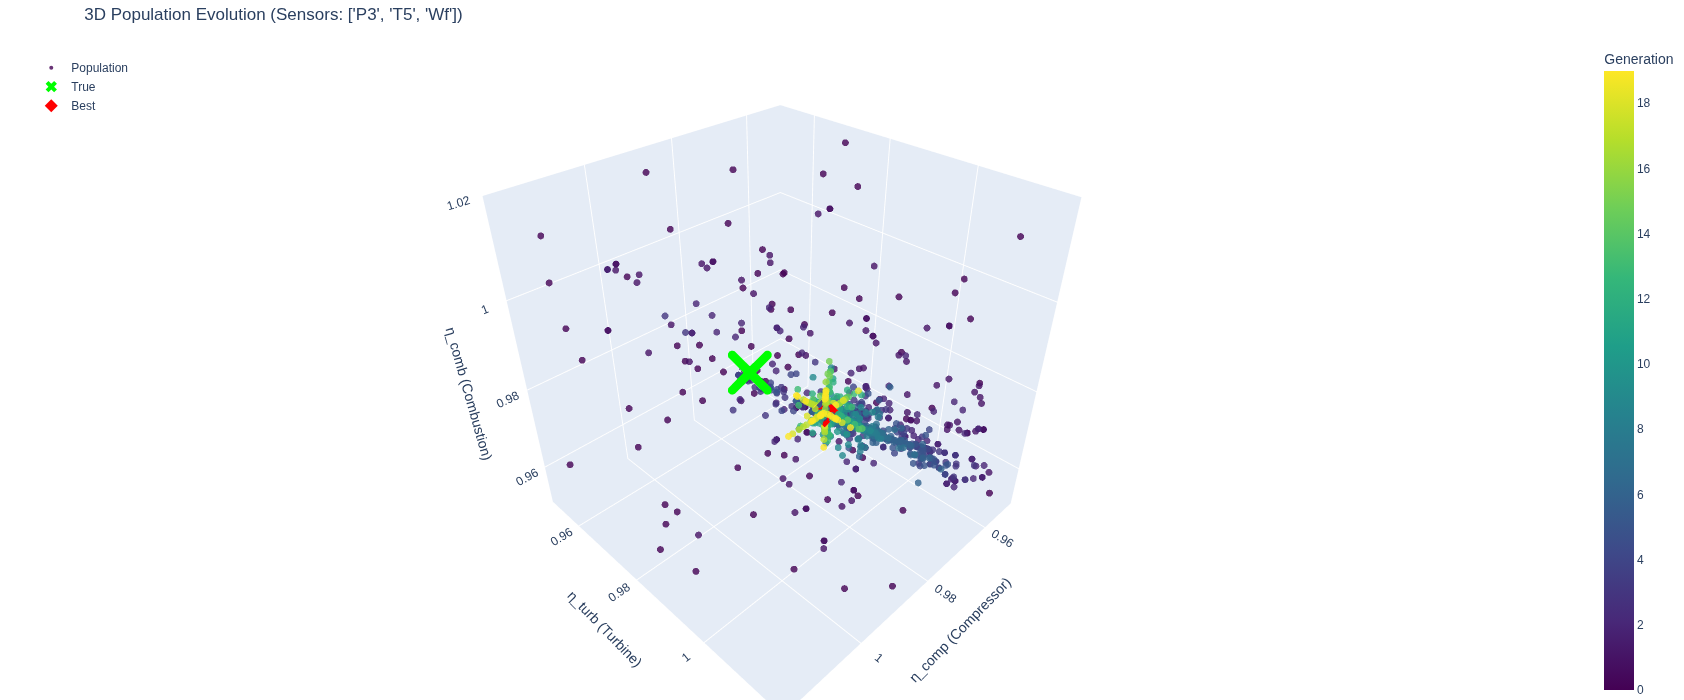

In [26]:
plot_ga_population_3d(ga, best_solution, true_health=[true_eta_comp, true_eta_turb,  true_eta_comb])

## Genetic Algorithm Notes and Observations 

**What was noticed:**  

From the GA runs, the **initial population** was not always within the defined bounds.  
Some estimated values were **unrealistic** and generated the exception:

invalid value encountered in sqrt from `turboreactors.py`.  
This same issue sometimes appeared even during:
```python
measured_series = list(h_SCSF(true_traj, S=sensors))
```
meaning some parameter combinations could still produce **non-physical states** ?

---

### What was done
- Implemented the **Genetic Algorithm (GA)** estimation for both 2 and 3 component cases.

- To solve the out-of-bound issue, we forced all outputs to stay **inside the valid bounds** during:

    - **Crossover**
    - **Mutation**
    - **Crossover + Mutation**

This ensures that every individual remains **physically valid** at each generation.



---

### Additional Observation
The current approach gives **good results for early flights**,  
but when using as initial value a point after many flights, the results become **less accurate**.  
From the figure, it seems that the GA **got stuck in a local solution**,   as the population concentrated around a region close to the true value but didn’t fully reach it.

or **Maybe the mutation step  is very low?**
### Next ?
The current approach only consider one measurement but in fact, we should consider:
- More measurements
- The temporal information : The estimation degrade over time
- Update the current GA workflow
- Add early stopping criteria  : idea:
  - 1. Fixed a number a iteration
  - 2. Minimum improvement : If after x generation there is no improvement compared to previous results, stop
- Explore better
- 
- **initialization strategies**
- Do a crossover ?
- Use logscale for plotting to clearly see the error rate
- Use a diferent approach to check if the point are local minima (local minima in 2D, 3D)
  

#### Othere remarks
- From 1 generation to another, we don't know if it is the same individual who contributed
- Plotting fitness scores for all generation could also be useful
- Also currently we plot the best of each generation, std. could be benefitial as well

Then :
- Add noise in the measurements.
See the file `genetic_algorithm_multiple_components` to learn more about it
